In [2]:
from CNN_2dhist_function import *

2026-02-19 12:14:27,163	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO: Pandarallel will run on 24 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


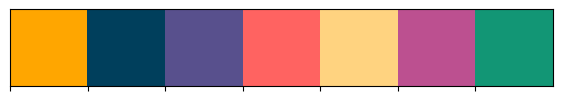

In [3]:
# Establecer la semilla para TensorFlow
tf.random.set_seed(42)

# Obtén el número de CPUs
num_cpus = psutil.cpu_count(logical=False)

path_data = "/home/nicolas/nico/Data/data_Paper_OGLE/"

datos = f"{path_data}Data/datos_ogle/datos"

path_datos_4 = datos + "/datos_ogle_4/I"

path_datos_3 = datos + "/datos_ogle_3/I"
path_datos = ["_","_","_",path_datos_3,path_datos_4]

rng = np.random.default_rng(42)

gyr = ["#ffa600",
        '#003f5c',
       "#58508d",
       "#ff6361",
       "#ffd380",
       "#bc5090",
       "#129675"
      ]
palet = sns.palplot(sns.color_palette(gyr))
sns.set_context("paper")
path = "/home/nicolas/nico/Data/data_Paper_OGLE/7_01_2024/"

In [3]:

catalog = pd.read_csv(f"{path}/0_catalogo.csv")

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
%%time
results_ids = []
for i in range(len(catalog)):
    results_ids.append(review_open_data.remote(catalog["ID"][i],path_datos,catalog["database"][i]))                                                                                                               

In [ ]:
%%time
df = pd.DataFrame(ray.get(results_ids),columns=["error",
                                            "ID", "database",
                                        "obs_eliminadas",
                                        "amplitud",
                                        "mag_mean",
                                        "mag_std",
                                        "err_mean",
                                        "err_std",
                                        "obs_final",
                                        "obs_inicial","baseline","cadence","cadence_sigma"])

In [ ]:
catalog = catalog[['ID', 'RA', 'DEC', 'types', 'database', 'field', 'Subtype', 'per']].merge(df,how="inner",on=["ID","database"])

In [ ]:
a, b = ra_dec_to_degrees(catalog["RA"],catalog["DEC"])

In [ ]:
catalog["ra_deg"] = a
catalog["dec_deg"] = b

In [ ]:
df = pd.read_csv(f"{path}/0_Catalog_TimeSerieInformation.csv")

In [ ]:
f"{path}/0_Catalog_TimeSerieInformation.csv"

In [ ]:
catalog.to_csv(f"{path}/0_Catalog_TimeSerieInformation.csv",index=False)

## Check Download

In [ ]:
catalog = pd.read_csv(f"{path}/0_Catalog_TimeSerieInformation.csv")

In [ ]:
error_descarga = catalog.loc[catalog["error"]==0]

In [ ]:
%%time
error_descarga["descarga_wget"] = error_descarga.apply(lambda row: descarga_wget(row["database"],
                                                                       row["ID"],
                                                                      path_datos_3,
                                                                      path_datos_4),axis=1)

In [ ]:
error_descarga[['ID', 'RA', 'DEC', 'types', 'database', 'field', 'Subtype', 'per']].to_csv(f"{path}/I_filter_data_missing.csv",index=False)

## Preprocesing

In [ ]:
catalog = pd.read_csv(f"{path}/0_Catalog_TimeSerieInformation.csv")

In [ ]:
df = catalog.groupby("types").count()[["ID"]].rename(columns={"ID":"Catalogo"})

In [ ]:
catalog = catalog.loc[catalog["error"]!=0]

In [ ]:
df["error download"] = df[["Catalogo"]].rename(columns={"Catalogo":"ID"}) - catalog.groupby("types").count()[["ID"]]

In [ ]:
quantile_1_percent = catalog['obs_final'].quantile(0.01)
quantile_99_percent = catalog['obs_final'].quantile(0.8933)

print("1% Quantile:", quantile_1_percent)
print("89% Quantile:", quantile_99_percent)


In [ ]:
df["Observaciones<60"] = catalog.loc[(catalog["obs_final"]<=60)|
                                     (catalog["obs_final"]==0)
                                    ].groupby("types").count()[["ID"]]

In [ ]:
catalog = catalog.loc[(catalog["obs_final"]>60)]

In [ ]:
sns.histplot(data=catalog,x=catalog["obs_eliminadas"] / catalog["obs_inicial"],bins=50,hue="types")
mean_sigma_clipping = round((catalog["obs_eliminadas"] / catalog["obs_inicial"]).mean() * 100,2)
plt.title(f"Percentage of Eliminated Observation \n mean {mean_sigma_clipping} %")


In [ ]:
catalog = catalog.sort_values(by="database",ascending=False).reset_index(drop=True)

In [ ]:
df["Duplicated ID"] = catalog.loc[catalog.duplicated(subset="ID")].groupby("types").count()[["ID"]]

In [ ]:
catalog = catalog.drop_duplicates(subset="ID",keep="first").reset_index(drop=True)

In [ ]:
catalog.to_csv(f"{path}/0_Catalog_TimeSerieInformation_AT.csv",index=False)

In [ ]:
catalog = pd.read_csv(f"{path}/0_Catalog_TimeSerieInformation_AT.csv")

In [ ]:
catalog_t = pd.read_csv(f"{path}/0_Catalog_TimeSerieInformation_DT.csv")

In [ ]:
catalog_t.loc[catalog_t["GroupID"].notna()].to_csv(f"{path}/0_Catalog_TimeSerieInformation_DT_possible_blended.csv",index=False)

In [ ]:
catalog_t = catalog_t.loc[catalog_t["GroupID"].isna()]

In [ ]:
catalog_t.to_csv(f"{path}/0_Catalog_TimeSerieInformation_DT_unique.csv",index=False)

In [ ]:
df["Topcat"] = catalog.groupby("types").count()[["ID"]] - catalog_t.groupby("types").count()[["ID"]]

In [ ]:
df["final"] = catalog_t.groupby("types").count()[["ID"]]

In [ ]:
df = df.fillna(0)


In [ ]:
path_save = "/home/nicolas/nico/Data/data_Paper_OGLE/7_01_2024/"
catalog = pd.read_csv(f"{path_save}/0_Catalog_TimeSerieInformation_DT_unique.csv")

In [ ]:
catalog = catalog.loc[(catalog["per"]!=0)&(catalog["per"].notna())] # one ECL star without period and 15 with nans

In [ ]:
cep_min = catalog.groupby("types").count().sort_values(by="ID",ascending=True)["ID"].values[0]

In [ ]:
df_split_random = split_random(catalog,cep_min,"Train_8")

In [ ]:
train_8 = df_split_random.loc[df_split_random["Train_8"].notna()]

In [ ]:
df_split_random.to_csv(f"{path}/0_Catalog_TimeSerieInformation_DT_Train_8.csv",index=False)

In [ ]:
catalog = catalog.loc[catalog["obs_final"]<=2000]

In [ ]:
def plot_obs_dist(df, split_name,path):
    sns.set_context("paper")
    gyr = ['#FFCF3D', "#890B96"]
    sns.set_palette(gyr)

    columns = ["obs_final", "amplitud", "mag_mean", "field", "err_mean", "per", "mag_std", "err_std"]
    labels = [r'$n_{obs}$', r'$Amplitude$', 'Mean Magnitude', "Field", 'Mean Error', 'Period', 
              'Magnitude standard deviations', 'Error standard deviations']
    log_scales = [True, True, False, False, True, True, True, False]
    x_ticks = [[10**2, 10**3, 10**4], [10**-1, 1, 10**1], None, None, [10**-2, 10**-1, 10**0], [10**-1, 10**1, 10**3],
               None, [0, 0.3, 0.6]]
    y_scale_log = [True, True, True, True, True, True, True, True]

    fig, axes = plt.subplots(2, 4, figsize=(10, 5))

    # Crear las leyendas una vez

    legend_labels = df[split_name].unique()
    legend_colors = gyr[:len(legend_labels)]

    # Crear una leyenda para toda la figura
    legend_elements = [plt.Line2D([0], [0], color=color, lw=4, label=label)
                       for label, color in zip(legend_labels, legend_colors)]

    for i, ax in enumerate(axes.flatten()):
        sns.histplot(ax=ax, data=df, x=columns[i], hue=split_name, bins=30, log_scale=log_scales[i], fill=True, common_norm=True, multiple="stack", palette=gyr)
        ks_test = stats.kstest(df.loc[df["database"]==3][columns[i]],df.loc[df["database"]==4][columns[i]])
        ks_test = np.round(ks_test[0],3)

        ax.set(xlabel=labels[i], ylabel="")
        ax.set_title(f' K-S: {ks_test}')
        if x_ticks[i] is not None:
            ax.set_xticks(x_ticks[i])
        if y_scale_log[i]:
            ax.set_yscale("log")

            # Calcular y establecer 4 y-ticks para cada subplot
            ymin, ymax = ax.get_ylim()
            yticks = np.logspace(np.log10(ymin+1e-3), np.log10(ymax), 4)  # Añadir un pequeño offset para evitar log(0)            print(yticks)# Añadir un pequeño offset para evitar log(0)
            ax.set_yticks(yticks)
            ax.set_yticklabels(yticks)
            ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda y, _: '${{10^{{{:d}}}}}$'.format(int(np.log10(y)))))
        ax.get_legend().remove()  # Remove the individual legend from each subplot

    plt.rc('xtick', labelsize=13)

    fig.legend(handles=legend_elements, loc='upper center', ncol=len(legend_labels), bbox_to_anchor=(0.5, 1.05))
    fig.tight_layout()
    plt.show()            
    return 

In [ ]:
#catalog = catalog.loc[catalog["per"]!=0]

In [ ]:
#plot_obs_dist(catalog,"database",path)

## Augmented data

In [ ]:
ogle = pd.read_csv(f"{path}/0_Catalog_TimeSerieInformation_DT_Train_8.csv")
le = preprocessing.LabelEncoder()
le.fit(ogle.types)
ogle["categorical_label"] = le.transform(ogle.types)
prueba_8mil = ogle.loc[ogle["Train_8"].notna()]

In [ ]:
ogle, train_number_ELL = balance_data(ogle, prueba_8mil)

In [ ]:
ogle, train_number_DST = balance_data(ogle, train_number_ELL)

In [ ]:
ogle, train_number_M = balance_data(ogle, train_number_DST)

In [ ]:
train_number_ELL,_ = data_augmented_parameter_creator(train_number_ELL)
train_number_DST,_ = data_augmented_parameter_creator(train_number_DST)
train_number_M,_ = data_augmented_parameter_creator(train_number_M)

In [ ]:
catalog = pd.read_csv(f"{path}/0_Catalog_TimeSerieInformation_DT_Train_8.csv")


In [ ]:
catalog.loc[(catalog["ID"].isin(train_number_ELL["ID"]))&
               catalog["Train_8"].isna(),"Train_NumberELL"] = "train"

In [ ]:
catalog.loc[(catalog["ID"].isin(train_number_DST["ID"]))&
               catalog["Train_8"].isna(),"Train_NumberDST"] = "train"

In [ ]:
catalog.loc[(catalog["ID"].isin(train_number_M["ID"]))&
               catalog["Train_8"].isna(),"Train_NumberM"] = "train"

In [ ]:
prueba_8mil["aug"] = 0
prueba_8mil["g"] = np.nan
prueba_8mil["bins"] = np.nan

catalog["aug"] = 0
catalog["g"] = np.nan
catalog["bins"] = np.nan


In [ ]:
prueba_8mil_2 = make_random_period(prueba_8mil)
train_number_ELL =  make_random_period(train_number_ELL,train_number_ELL.groupby("categorical_label")["ID"].count().max())
train_number_DST =  make_random_period(train_number_DST,train_number_DST.groupby("categorical_label")["ID"].count().max())
train_number_M =  make_random_period(train_number_M,train_number_M.groupby("categorical_label")["ID"].count().max())

In [ ]:
train_number_M.groupby(["categorical_label","types"]).count()

In [ ]:
train_number_ELL.to_csv(f"{path}/train_number_ELL.csv",index=False)
train_number_DST.to_csv(f"{path}/train_number_DST.csv",index=False)
train_number_M.to_csv(f"{path}/train_number_M.csv",index=False)
prueba_8mil_2.to_csv(f"{path}/prueba_8mil.csv",index=False)
catalog.to_csv(f"{path}/0_Catalog_TimeSerieInformation_DT_Augmented.csv",index=False)

## Plots

In [ ]:
def plot_histograms(estrellas_plot, path_datos, norm, path):
    fig, ax = plt.subplots(len(estrellas_plot), 2, figsize=(5, 16), sharex="col")
    for i in range(len(estrellas_plot)):
        fase, mag, t_vsx = fase_datos(path_datos, estrellas_plot["database"][i], estrellas_plot["ID"][i], estrellas_plot["per"][i])

        ax[i, 0].set_ylim(mag.max(), mag.min()- (mag.max() - mag.min())/4)
        ax[i, 0].set_yticks(np.linspace(mag.min() + (mag.max() - mag.min()) / 10, mag.max() - (mag.max() - mag.min()) / 10, 4))
        ax[i, 0].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        sns.scatterplot(x=fase, y=mag, c=t_vsx, s=15, ax=ax[i, 0])
        ax[i, 0].set(xlabel='', ylabel='')
        text = f"{estrellas_plot['ID'][i]} [{estrellas_plot['types'][i]}]"
        ax[i, 0].text(0.05, 0.95, text, transform=ax[i, 0].transAxes, fontsize=9, verticalalignment='top')

        hdu = make_2d_histogram(32 + 1, 32 + 1, mag, fase, norm_max=norm)
        ax[i, 1].imshow(hdu.data, interpolation='nearest', aspect='auto')
        ax[i, 1].set_yticks([])
        ax[i, 1].set_xticks([])
        ax[i, 1].tick_params(left=False, bottom=False)
        ax[i, 1].set_xlabel("")
        ax[i, 1].set_ylabel("")

    fig.text(0.5, 0, "Phase", size=13)
    fig.text(-0.01, 0.5, "I Mag", size=13, rotation=90)
    fig.tight_layout()
    plt.subplots_adjust(wspace=0.01, hspace=0.01)
    plt.savefig(f"{path}hist_2d_fase.pdf", bbox_inches="tight", pad_inches=0)
    return hdu


In [ ]:
estrellas = ['OGLE-GD-RRLYR-04519', 'OGLE-BLG-LPV-240852', "OGLE-SMC-ECL-2344", "OGLE-LMC-CEP-2430", 'OGLE-LMC-LPV-83641', "OGLE-BLG-DSCT-00245", "OGLE-BLG-ELL-007122"]


catalog = pd.read_csv(f"{path}/0_Catalog_TimeSerieInformation_DT_unique.csv")
catalog = catalog.loc[catalog["per"]!=0]

estrellas_plot = catalog.loc[catalog["ID"].isin(estrellas)].reset_index(drop=True)

random = pd.read_csv(f"{path}/train_number_M.csv")
rndm = random.loc[random["categorical_label"]==7].sample(1).reset_index(drop=True)
rndm["types"]="Random"

estrellas_plot = pd.concat([estrellas_plot,rndm]).reset_index(drop=True)

replacement_dict = {
    "cep": "CEP",
    "ecl": "E",
    "dsct": "DST",
    "ELL": "ELL",
    "Mira": "M",
    "rrlyr": "RR",
    "lpv": "LPV",
    "Random": "Rndm"
}

estrellas_plot["types"] = estrellas_plot["types"].replace(replacement_dict)

a = plot_histograms(estrellas_plot, path_datos,"max",path)

In [ ]:
path

In [ ]:
train_8 = pd.read_csv(f"{path}/0_Catalog_TimeSerieInformation_DT_Train_8.csv")

In [ ]:
plot_obs_dist(train_8,"Train_8",path)

### Hacer HDF5 

In [ ]:
ray.init()

In [ ]:
train_number_ELL = pd.read_csv(f"{path}/train_number_ELL.csv")
train_number_DST = pd.read_csv(f"{path}/train_number_DST.csv")
train_number_M = pd.read_csv(f"{path}/train_number_M.csv")
prueba_8mil = pd.read_csv(f"{path}/prueba_8mil.csv")
ogle = pd.read_csv(f"{path}/0_Catalog_TimeSerieInformation_DT_Augmented.csv")

In [ ]:
data_total = h5py.File(f'{path}/Data.hdf5', 'w')
for test,name  in zip([prueba_8mil,
                       train_number_ELL,
                       train_number_DST,
                       train_number_M],["Number_CEP","Number_ELL",
                                                                 "Number_DST",
                                                                 "Number_M"]):
    data_hist = create_hdf5(test,path_datos,rng)
    data_total.create_dataset(f'{str(name)}_label', data=test['categorical_label'])
    data_total.create_dataset(f'{str(name)}_data', data=data_hist)

In [ ]:
data_total.close()

In [ ]:
data_hist = create_hdf5(ogle,path_datos,rng)
OGLE = h5py.File(f'{path}/OGLE.hdf5', 'w')
OGLE.create_dataset(f'{path}/OGLE_label', data=ogle['categorical_label'])
OGLE.create_dataset(f'{path}/OGLE_images', data=data_hist)

In [ ]:
data_total.close()

In [ ]:
OGLE.close()

In [ ]:
df = pd.read_csv(f"{path}/train_number_M.csv")
data = h5py.File(f"{path}Data.hdf5", 'r+')
ID_cep = 'OGLE-GD-CEP-0028'
ID_dsct = 'OGLE-BLG-DSCT-08845'
ID_ELL = 'OGLE-BLG-ELL-016777'
# Creación de la figura y los ejes
fig, axes = plt.subplots(3, 3, figsize=(10,10), sharex=True, sharey=True)
plt.tight_layout(pad=0.2)

# Ciclo para cada grupo de estrellas
for fila, stars_group in enumerate([ID_dsct,ID_ELL, ID_cep]):
    df_plot = df.loc[(df["ID"] == stars_group) & (df["types"].str.split("_").str[1] != "random")]
    df_plot.loc[df_plot["bins"].isna(), "bins"] = df_plot["obs_final"]
    df_plot.loc[df_plot["aug"] == 0, "g"] = 0
    df_plot["phi"] = df_plot["g"] / df_plot["per"]
    df_plot = df_plot.sort_values(by="phi")
    df_plot.loc[df_plot["types"] == "cep", "types"] = "Cepheids"
    df_plot.loc[df_plot["types"] == "dsct", "types"] = "Delta Scuti"
    df_plot.loc[df_plot["types"] == "ELL", "types"] = "Ellipsoidal"
    
    for col, star in enumerate(df_plot.index):
        fill_subplot(axes[fila, col], df_plot, star, data)
        axes[fila, col].set_yticks([])
        if col == 0:
            axes[fila, col].set_ylabel(df_plot.loc[star]["types"], fontsize=25)

        if (col == 0) & (fila == 2):
            axes[fila, col].set_xlabel("Original", fontsize=25)
        if (col != 0) & (fila == 2):
            axes[fila, col].set_xlabel(f"Augmented {col}", fontsize=25)

        axes[fila, col].set_xticks([])
    
    # Eliminar los ejes vacíos
    for col in range(len(df_plot.index), 3):
        fig.delaxes(axes[fila, col])

plt.subplots_adjust(hspace=0.2)
plt.savefig(f"{path}Augmented_stars.pdf", bbox_inches="tight")
plt.show()

## Time to Create 2d Histograms

In [ ]:
ray.init()


In [ ]:
prueba_8mil = pd.read_csv(f"{path}/prueba_8mil.csv")

In [ ]:
t0 = time.time()
data_hist = create_hdf5(prueba_8mil.reset_index(drop=True),path_datos,rng)
t1 = time.time() - t0

In [ ]:
t1

In [ ]:
ogle = pd.read_csv(f"{path}/0_Catalog_TimeSerieInformation_DT_Augmented.csv")
df = ogle.sample(10000).reset_index(drop=True)

In [ ]:
result = np.zeros((10000,3,2))
for i in range(10000):
    _,b = make_lc_hist_with_time(df["ID"][i],df["per"][i],
                                  path_datos,
                                  df["database"][i],
                                  df["aug"][i],
                                  rng,
                                  df["g"][i],
                                  df["bins"][i])
    result[i] = b[["time","percentage"]].values

In [ ]:
df_tiempo = pd.DataFrame(result.mean(axis=0),columns=["Mean_time","Mean_percentage"],
                                index=["load_csv","clean_data","histogram"])

In [ ]:
df_tiempo[["Std_time","Std_percentage"]] = result.std(axis=0)

The 33 \% is used for open the data, the 37\% is used for phase folded and sigma clipping and the 30\% is for create the 2d histogram

## Observational Table

In [ ]:
#Change path because the use of docker
path = '/project/nico/Data/data_Paper_OGLE/7_01_2024/'

In [ ]:
observational_table = prueba_8mil.loc[prueba_8mil["categorical_label"]!=7].groupby(["types","field"]).count()[["ID"]]

In [ ]:
observational_table["per_C1"] = prueba_8mil.loc[prueba_8mil["categorical_label"]!=7].groupby(["types","field"])["per"].quantile(0.1)
observational_table["per_C9"] = prueba_8mil.loc[prueba_8mil["categorical_label"]!=7].groupby(["types","field"])["per"].quantile(0.9)

observational_table["amplitude_C1"] = prueba_8mil.loc[prueba_8mil["categorical_label"]!=7].groupby(["types","field"])["amplitud"].quantile(0.1)
observational_table["amplitude_C9"] = prueba_8mil.loc[prueba_8mil["categorical_label"]!=7].groupby(["types","field"])["amplitud"].quantile(0.9)

In [ ]:
print(observational_table.round(2).to_latex())

In [ ]:
train_number_M.groupby("categorical_label").count()

## Entrenar

In [ ]:
#Change path because the use of docker
path = '/project/nico/Data/data_Paper_OGLE/7_01_2024/'

In [ ]:
train_number_ELL = pd.read_csv(f"{path}/train_number_ELL.csv")
train_number_DST = pd.read_csv(f"{path}/train_number_DST.csv")
train_number_M = pd.read_csv(f"{path}/train_number_M.csv")
prueba_8mil = pd.read_csv(f"{path}/prueba_8mil.csv")

In [ ]:
data = h5py.File(f"{path}/Data.hdf5", 'r+')

In [ ]:
df_lista = [prueba_8mil,train_number_ELL,train_number_DST,train_number_M]
keys_lista = ['Number_CEP','Number_ELL','Number_DST', 'Number_M']

In [ ]:
train_models(df_lista, keys_lista, data, prueba_8mil,path,epochs=1000, use_balanced_generator=False)

In [ ]:
train_models(df_lista, keys_lista, data, prueba_8mil,path,epochs=1000, use_balanced_generator=True)

## Results

In [ ]:
df_2 = pd.read_csv(f"{path}history_softmax_batchBalanced_Number_DST.csv")

In [ ]:
df = pd.read_csv(f"{path}history_softmax_Number_DST.csv")

In [ ]:
amarillo_train = "#FFCF3D"
purpura_val = "#890B96"
file_names = ['history_softmax_Number_CEP', 'history_softmax_Number_DST', 'history_softmax_Number_ELL', 'history_softmax_Number_M']

title_names = [
    'Train-8 U.',
    'Train-22',
    'Train-37',
    "Train-60"]
plot_accuracy_and_loss(path,file_names, title_names, amarillo_train, purpura_val,f"{path}/training.pdf")

## Test time 

In [ ]:
data = h5py.File(f"{path}/Data.hdf5", 'r+')
model = make_model()
prueba = "training_softmax_Number_DST"
model.load_weights(f"{path}/{prueba}/cp.ckpt")


In [ ]:
tiempo = []
for i in range(1000):
    t0 = time.time()
    model.predict(data["Number_CEP_data"][:1000])
    tiempo.append(time.time()-t0)

### Acc, Rec, F1

In [ ]:
tests = ['training_softmax_Number_CEP','training_softmax_Number_ELL', 'training_softmax_batchBalanced_Number_ELL','training_softmax_Number_DST', 'training_softmax_batchBalanced_Number_DST', 'training_softmax_Number_M', 'training_softmax_batchBalanced_Number_M']


In [ ]:
acc,f1,rec,prec = metrics_per_model(tests,"Number_CEP",path)

In [ ]:
df = pd.DataFrame({"name":tests,"acc":acc,"f1":f1,"rec":rec,"prec":prec})

In [ ]:
print(pd.DataFrame({"name":tests,"acc":acc,"f1":f1,"rec":rec,"prec":prec}).round(3).to_latex())

In [ ]:
tests = ['training_softmax_Number_ELL', 'training_softmax_batchBalanced_Number_ELL','training_softmax_Number_DST', 'training_softmax_batchBalanced_Number_DST', 'training_softmax_Number_M', 'training_softmax_batchBalanced_Number_M']
titles = ['Train-22 Data Augmentation',
         'Train-22 Batch Balanced','Train-37 Data Augmentation',
         'Train-37 Batch Balanced',
         'Train-60 Data Augmentation',
         'Train-60 Batch Balanced']

test = run_analysis(tests,titles,"Number_CEP",path)

In [ ]:
test_under = undersampling_CM("training_softmax_Number_CEP",'Train-8 Undersampling',"Number_CEP",path)

In [ ]:
df = metricas(test["categorical_label"],test["label_predict_training_softmax_batchBalanced_Number_M"])

In [ ]:
print(pd.DataFrame(df).round(3).T.to_latex())

In [ ]:
df_8mil = pd.read_csv(f"{path}prueba_8mil.csv")
idx_test = df_8mil.loc[df_8mil["Train_8"]=="test"].index.values
model_softmax = make_model()
model_softmax.load_weights(f"{path}{test}/cp.ckpt")
data = h5py.File(f"{path}Data.hdf5", 'r+')
name = "Number_CEP"
test = 'training_softmax_batchBalanced_Number_M'
# Prepare data generator
test_datagen = ImageDataGenerator()
test_gen = test_datagen.flow(
    data[name+"_data"][idx_test],
    data[name+"_label"][idx_test],
    batch_size=64
)


In [ ]:
df = pd.DataFrame(model_softmax.predict(test_gen.x),columns=['ELL', 'Mira', 'cep', 'dsct', 'ecl', 'lpv', 'rrlyr',"random"])


In [ ]:
df["type"] = df_8mil.loc[df_8mil["Train_8"]=="test"].reset_index(drop=True)["types"]

In [ ]:
df["ID"] = df_8mil.loc[df_8mil["Train_8"]=="test"].reset_index(drop=True)["ID"]

In [ ]:
df['Max_Column'] = df[['ELL', 'Mira', 'cep', 'dsct', 'ecl', 'lpv', 'rrlyr',"random"]].idxmax(axis=1)

In [ ]:
df["type"].str[-6:] !="random"

In [ ]:
index =df.loc[(df["Max_Column"]=="random")&
       (df["type"].str[-6:] !="random")&
        (df["type"]!="lpv")&(df["type"]!="Mira")].index

In [ ]:
df.loc[(df["Max_Column"]=="random")&
       (df["type"].str[-6:] !="random")&
        (df["type"]!="lpv")&(df["type"]!="Mira")]

In [ ]:
df.iloc[idx]["ID"]

In [ ]:
import matplotlib.pyplot as plt

# Suponiendo que test_gen.x es tu dataset y 'index' es la variable que contiene los índices
fig, axs = plt.subplots(4, 3, figsize=(10, 10))

# Flatten the 2D array of subplots into a 1D array
axs = axs.flatten()

# Iterar sobre los índices y subplots para mostrar las imágenes
for idx, ax in zip(index, axs):
    ax.imshow(test_gen.x[idx],aspect="auto")
    ax.set_title(df.iloc[idx]["ID"])
    ax.axis('off')  # Opcional: desactiva los ejes para una mejor visualización

plt.subplots_adjust(wspace=0.1, hspace=0.2)  # Reducir el espacio entre los subplots en las columnas y filas
plt.show()



## Time to Run RF + CNN

In [4]:
test = 'training_softmax_Number_CEP/'
test_data_name =  'Number_CEP'

In [8]:
path = "/home/nicolas/nico/Data/data_Paper_OGLE/7_01_2024/"

In [9]:
data = h5py.File(f"{path}Data.hdf5", 'r+')
#ogle = pd.read_csv("catalogos/ogle_no_usado.csv")
df_8mil = pd.read_csv(f"{path}prueba_8mil.csv")
idx_test = df_8mil.loc[df_8mil["Train_8"]=="test"].index.values
model_softmax = make_model()
model_softmax.load_weights(f"{path}training_softmax_Number_M/cp.ckpt")

2026-02-19 12:15:23.873931: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
df = pd.DataFrame(model_softmax.predict(data["Number_CEP_data"][:]),columns=['ELL', 'M', 'CEP', 'DST', 'E', 'LPV', 'RR',"Rndm"])
df_test = pd.DataFrame(model_softmax.predict(data["Number_CEP_data"][idx_test]),columns=['ELL', 'M', 'CEP', 'DST', 'E', 'LPV', 'RR',"Rndm"])


2026-02-19 12:15:30.773481: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2026-02-19 12:15:30.773763: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 2419200000 Hz


In [11]:
df_number_CEP = pd.read_csv(f"{path}prueba_8mil.csv")

In [12]:
df_number_CEP = pd.concat([df_number_CEP,df],axis=1)

In [13]:
df_number_CEP = df_number_CEP.loc[df_number_CEP["aug"]==0]

In [14]:
df_number_CEP = df_number_CEP.loc[df_number_CEP["Train_8"]!="test"]

In [15]:
df_8mil_test = df_8mil.loc[idx_test].reset_index(drop=True)

In [16]:
df_test = df_test.reset_index(drop=True)

In [17]:
df_8mil_test = pd.concat([df_8mil_test,df_test],axis=1) 

In [18]:
X_train = df_number_CEP[['ELL', 'M', 'CEP', 'DST', 'E', 'LPV', 'RR',"Rndm",
         "per","amplitud","types","categorical_label"]]
X_test = df_8mil_test[['ELL', 'M', 'CEP', 'DST', 'E', 'LPV', 'RR',"Rndm",
         "per","amplitud","types","categorical_label"]]


In [20]:
import sys
import sklearn
import imblearn
import numpy as np
import scipy
import pandas as pd
import joblib

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("pandas:", pd.__version__)
print("joblib:", joblib.__version__)


Python: 3.8.15 | packaged by conda-forge | (default, Nov 22 2022, 08:46:39) 
[GCC 10.4.0]
scikit-learn: 1.0.2
imbalanced-learn: 0.12.4
numpy: 1.23.5
scipy: 1.10.1
pandas: 2.0.3
joblib: 1.4.2


In [22]:

# ------------------------------------------------------------------
# 1. Definir el clasificador
# ------------------------------------------------------------------
brf_clf = BalancedRandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    bootstrap=False,
    random_state=1,
    n_jobs=-1
)

# ------------------------------------------------------------------
# 2. Barajar datos
# ------------------------------------------------------------------
X_train_shuffled, y_train_shuffled = shuffle(
    X_train.drop(columns={"types", "categorical_label"}),
    X_train["categorical_label"],
    random_state=42
)

# ------------------------------------------------------------------
# 3. Entrenar el modelo
# ------------------------------------------------------------------
brf_clf.fit(X_train_shuffled, y_train_shuffled)


/home/nicolas/.local/share/mamba/envs/CNN_OGLE_legacy/lib/python3.8/site-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/home/nicolas/.local/share/mamba/envs/CNN_OGLE_legacy/lib/python3.8/site-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(


BalancedRandomForestClassifier(bootstrap=False, n_estimators=500, n_jobs=-1,
                               random_state=1)

In [38]:
X_test

,ELL,M,CEP,DST,E,LPV,RR,Rndm,per,amplitud,types,categorical_label
0,6.957165e-04,1.230067e-02,1.077082e-03,1.508053e-02,0.000842,0.831679,2.009408e-03,0.136315,53.840000,0.470,lpv,5
1,1.999814e-07,1.103202e-05,3.534903e-04,8.544503e-02,0.000004,0.888712,2.534782e-02,0.000127,14.370000,0.080,lpv,5
2,1.495117e-05,2.640651e-03,1.408627e-04,6.416920e-03,0.000028,0.983221,5.629522e-03,0.001908,23.085000,0.156,lpv,5
3,4.219868e-07,1.034719e-06,1.430284e-06,1.044308e-04,0.000012,0.983140,4.247342e-06,0.016736,16.073000,0.057,lpv,5
4,7.967126e-06,1.877510e-06,5.225692e-06,5.921202e-04,0.000172,0.961648,5.652923e-06,0.037567,5.682500,0.049,lpv,5
...,...,...,...,...,...,...,...,...,...,...,...,...
11819,3.007011e-05,4.727456e-06,1.082702e-05,1.226763e-06,0.000175,0.065782,2.552203e-06,0.933993,0.821941,0.804,rrlyr_random,7
11820,2.138554e-06,2.197998e-06,7.732388e-04,9.219497e-07,0.000006,0.017197,6.397205e-05,0.981954,0.401863,0.290,rrlyr_random,7
11821,1.216610e-07,5.574381e-09,8.233272e-07,1.039794e-07,0.000021,0.000828,6.032012e-09,0.999150,0.531932,0.473,rrlyr_random,7
11822,3.586979e-06,8.737699e-07,2.539648e-05,4.231884e-07,0.000226,0.004145,6.002498e-07,0.995598,0.594324,0.483,rrlyr_random,7


In [47]:
X_test.drop_duplicates(subset=["types", "categorical_label"]).sort_values(by="categorical_label")["types"]


2660              ELL
269              Mira
505               cep
325              dsct
267               ecl
0                 lpv
367             rrlyr
10346      ELL_random
10557     Mira_random
10767      cep_random
10977     dsct_random
11188      ecl_random
11400      lpv_random
11612    rrlyr_random
Name: types, dtype: object

In [32]:
import joblib

joblib.dump(brf_clf, "balanced_random_forest_model.joblib")


['balanced_random_forest_model.joblib']

In [33]:
def train_random_forest(X_test, y_test,path,clf):
    # Crea el clasificador Random Forest
        
    # Predice las clases para el conjunto de test
    y_pred = clf.predict(X_test)
    
    # Crea una figura y ejes para la trama
    fig, ax = plt.subplots(figsize=(8, 8))

    array, annot = C_M(y_test, y_pred)
    sns.heatmap(array, annot=annot, fmt='', vmin=0, vmax=np.sum(array, axis=1)[0], cmap="BuPu",
                annot_kws={"fontsize":15}, linewidth=1, ax=ax, cbar=False)
    
    ax.set_yticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5])
    ax.set_yticklabels(['ELL', 'M', 'CEP', 'DST', 'E', 'LPV', 'RR',"Rndm"], fontsize=15)
    ax.set_ylabel('True Label', fontsize=20)
    
    ax.set_xticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5])
    ax.set_xticklabels(['ELL', 'M', 'CEP', 'DST', 'E', 'LPV', 'RR',"Rndm"], fontsize=15)
    ax.set_xlabel('Predicted Label', fontsize=20)
    
    # Add title and F1 Score
    # Calculate F1 Score
    f1 = f1_score(y_test, y_pred, average='weighted')
    ax.set_title(f'CNN+RF\nF1 Score: {f1:.2f}', fontsize=20)

    fig.tight_layout(pad=0)
    plt.savefig(f"{path}CNN_And_RF.pdf", bbox_inches="tight")
    
    # Guarda el modelo entrenado en el mismo path
    joblib.dump(clf, f"{path}trained_random_forest.joblib")
    return

In [26]:
#X_test.loc[X_test["types"]=="lpv","per"] = X_test.loc[X_test["types"]=="lpv"]["per"]

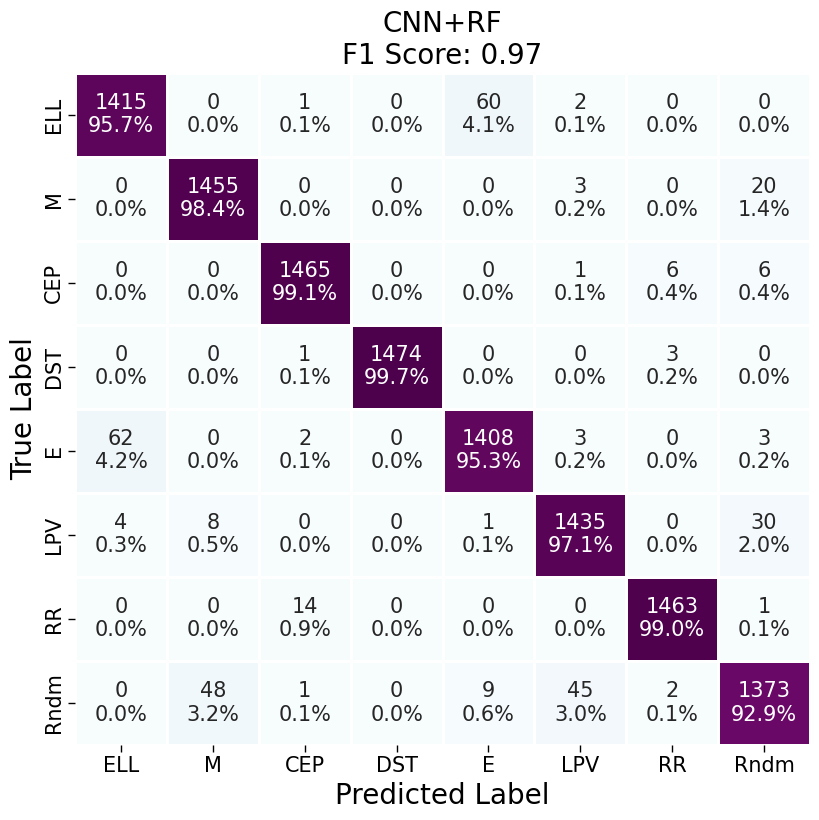

In [34]:
y_pred = train_random_forest(X_test.drop(columns={"types","categorical_label"}),
                   X_test["categorical_label"],path,brf_clf)